# Phần 1: Khám phá dữ liệu (EDA)
House Price Prediction

In [2]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_raw_data

df = load_raw_data('../data/raw/modified_data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

In [ ]:
df.describe().T

In [4]:
# Kiểm tra dữ liệu bất thường
print('price = 0:', (df['price']==0).sum())
print('bedrooms = 0:', (df['bedrooms']==0).sum())
print('bathrooms = 0:', (df['bathrooms']==0).sum())

price = 0: 49
bedrooms = 0: 2
bathrooms = 0: 2


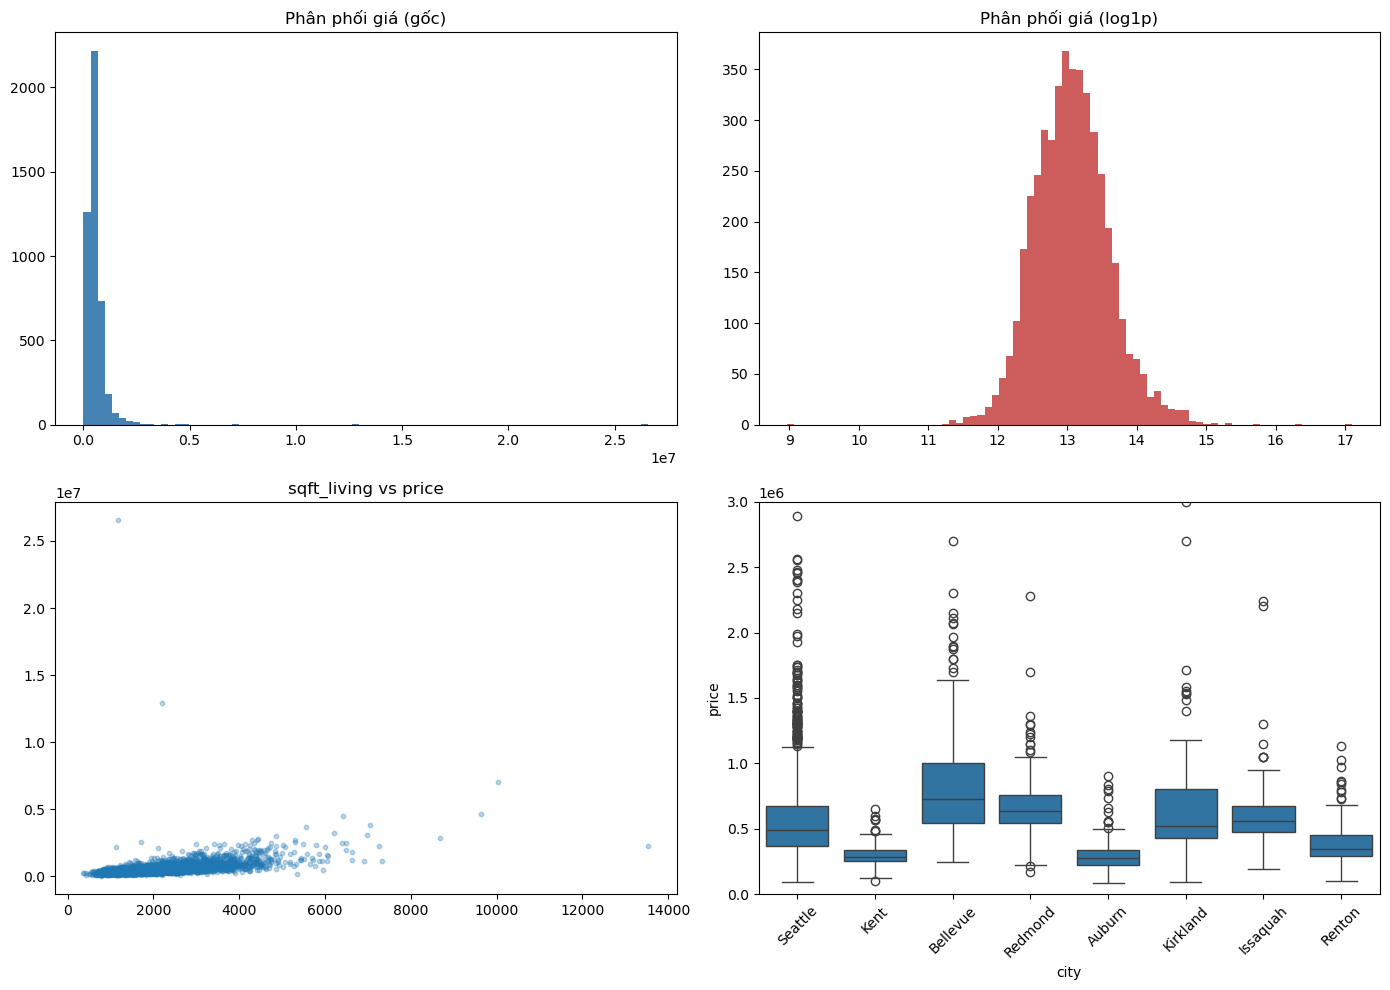

In [5]:
df_viz = df[df['price'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df_viz['price'], bins=80, color='steelblue')
axes[0,0].set_title('Phân phối giá (gốc)')

axes[0,1].hist(np.log1p(df_viz['price']), bins=80, color='indianred')
axes[0,1].set_title('Phân phối giá (log1p)')

axes[1,0].scatter(df_viz['sqft_living'], df_viz['price'], alpha=0.3, s=10)
axes[1,0].set_title('sqft_living vs price')

top_cities = df_viz['city'].value_counts().head(8).index
sns.boxplot(data=df_viz[df_viz['city'].isin(top_cities)], x='city', y='price', ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_ylim(0, 3_000_000)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_charts.png', dpi=110)
plt.show()

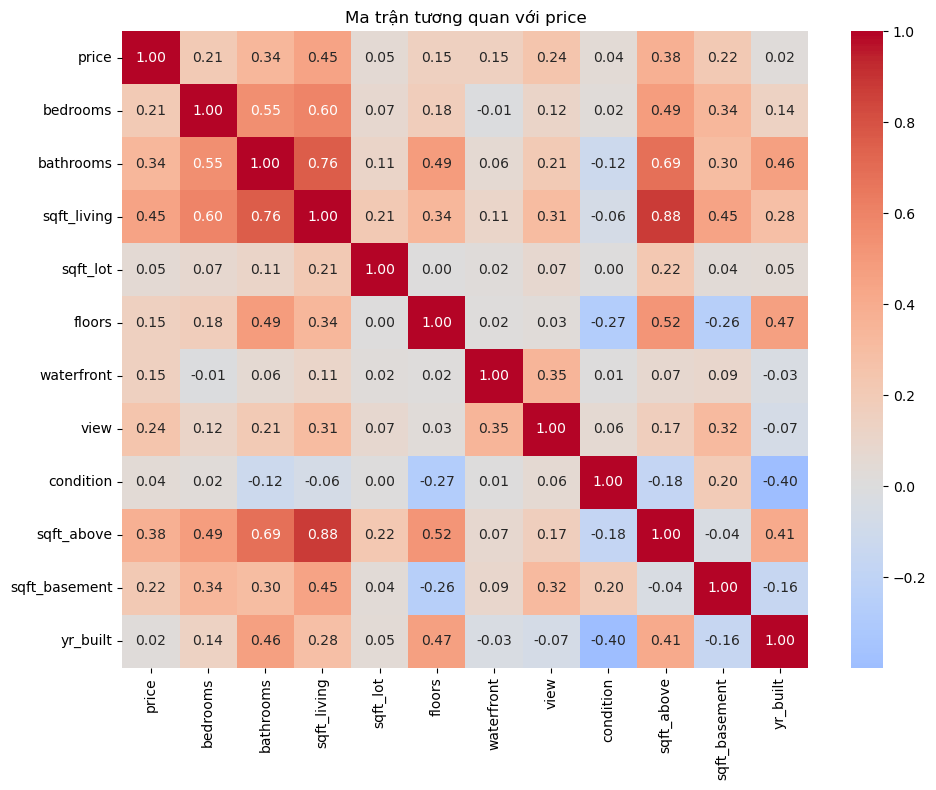

price            1.000000
sqft_living      0.445494
sqft_above       0.380661
bathrooms        0.341126
view             0.242587
sqft_basement    0.217782
bedrooms         0.210228
floors           0.152758
waterfront       0.150083
sqft_lot         0.051347
condition        0.038892
yr_built         0.021757
Name: price, dtype: float64

In [6]:
numeric_cols = ['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors',
                'waterfront','view','condition','sqft_above','sqft_basement','yr_built']
corr = df_viz[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Ma trận tương quan với price')
plt.tight_layout()
plt.savefig('../outputs/figures/corr_heatmap.png', dpi=110)
plt.show()

corr['price'].sort_values(ascending=False)